In [ ]:
# Install YOLOv8 and Roboflow
!pip install -q ultralytics roboflow

import torch
import os
from ultralytics import YOLO
from roboflow import Roboflow
from getpass import getpass

# Hardware Verification
device = 0 if torch.cuda.is_available() else 'cpu'
if device == 0:
    print(f"✅ GPU Accelerator Active: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: No GPU detected. Training will be significantly slower.")

✅ GPU Accelerator Active: Tesla T4


In [ ]:
print("🔑 Paste your Roboflow API Key:")
api_key = getpass()

try:
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("indian-institute-of-technology-madras-xamot").project("pothole-detection-huf2x")
    dataset = project.version(1).download("yolov8")

    import yaml
    with open(dataset.location + '/data.yaml') as f:
        config = yaml.safe_load(f)

    print(f"✅ Dataset downloaded at: {dataset.location}")
    print(f"✅ Classes: {config['names']}")
    print(f"✅ Number of classes: {config['nc']}")

    # Fix paths in data.yaml
    config['train'] = os.path.join(dataset.location, 'train/images')
    config['val']   = os.path.join(dataset.location, 'valid/images')
    config['test']  = os.path.join(dataset.location, 'test/images')

    with open('/content/data.yaml', 'w') as f:
        yaml.dump(config, f)

    # Count images
    train_imgs = len(os.listdir(config['train']))
    val_imgs   = len(os.listdir(config['val']))
    print(f"📊 Train images: {train_imgs}")
    print(f"📊 Val images:   {val_imgs}")

except Exception as e:
    print(f"❌ Error: {e}")

🔑 Paste your Roboflow API Key:
··········
loading Roboflow workspace...
loading Roboflow project...
✅ Dataset downloaded at: /content/Pothole-detection-1
✅ Classes: ['crocodile crack', 'longitudinal crack', 'pothole']
✅ Number of classes: 3
📊 Train images: 1906
📊 Val images:   542


In [ ]:
from ultralytics import YOLO

# 1. Start with Small (S) - Nano is too weak for complex cracks
model = YOLO('yolov8s.pt')

# 2. Optimized Training for 1,906 Images
results = model.train(
    data='/content/data.yaml',
    epochs=100,          # Increased from 30 to 100
    imgsz=640,
    batch=16,
    patience=20,         # Don't stop early!

    # --- AUGMENTATION (The Secret Sauce) ---
    degrees=15.0,        # Rotate images
    flipud=0.5,          # Flip upside down (good for road views)
    fliplr=0.5,          # Flip left/right
    mosaic=1.0,          # Combine 4 images into 1 (ESSENTIAL for small objects)
    mixup=0.1,           # Blend images together

    # --- OPTIMIZATION ---
    lr0=0.01,            # Initial learning rate
    lrf=0.01,            # Final learning rate
    warmup_epochs=3.0,

    project="SafeQ_Final",
    name="Hazard_Detection_Deep",
    verbose=False
)

# 3. Print Final Verified Scores
metrics = results.results_dict
print("\n" + "="*30)
print(f"🎯 NEW mAP50: {metrics['metrics/mAP50(B)']: .4f}")
print("="*30)


🎯 NEW mAP50:  0.2418


In [ ]:
import yaml, os, glob

with open('/content/data.yaml') as f:
    cfg = yaml.safe_load(f)

print("="*50)
print("🔍 DIAGNOSTIC REPORT")
print("="*50)
print(f"Classes: {cfg['names']}")
print(f"Num Classes: {cfg['nc']}")

for split in ['train', 'val']:
    img_dir = cfg[split]
    lbl_dir = img_dir.replace('images', 'labels')

    imgs   = len(glob.glob(img_dir + '/*'))
    labels = len(glob.glob(lbl_dir + '/*'))
    empty  = sum(1 for f in glob.glob(lbl_dir+'/*.txt')
                 if os.path.getsize(f) == 0)

    print(f"\n📂 {split.upper()}:")
    print(f"   Images:       {imgs}")
    print(f"   Labels:       {labels}")
    print(f"   Empty labels: {empty}")
    print(f"   Match: {'✅' if imgs==labels else '❌ MISMATCH'}")

🔍 DIAGNOSTIC REPORT
Classes: ['crocodile crack', 'longitudinal crack', 'pothole']
Num Classes: 3

📂 TRAIN:
   Images:       1906
   Labels:       1906
   Empty labels: 1
   Match: ✅

📂 VAL:
   Images:       542
   Labels:       542
   Empty labels: 0
   Match: ✅


🔍 TRAINING ANALYSIS
✅ Found: /content/runs/detect/SafeQ_Final/Hazard_Detection_Deep/results.csv

⏱️  Total epochs run: 57

📋 Available columns:
   epoch
   time
   train/box_loss
   train/cls_loss
   train/dfl_loss
   metrics/precision(B)
   metrics/recall(B)
   metrics/mAP50(B)
   metrics/mAP50-95(B)
   val/box_loss
   val/cls_loss
   val/dfl_loss
   lr/pg0
   lr/pg1
   lr/pg2

🏆 Best epoch:  37/57
🏆 Best mAP50:  0.2419


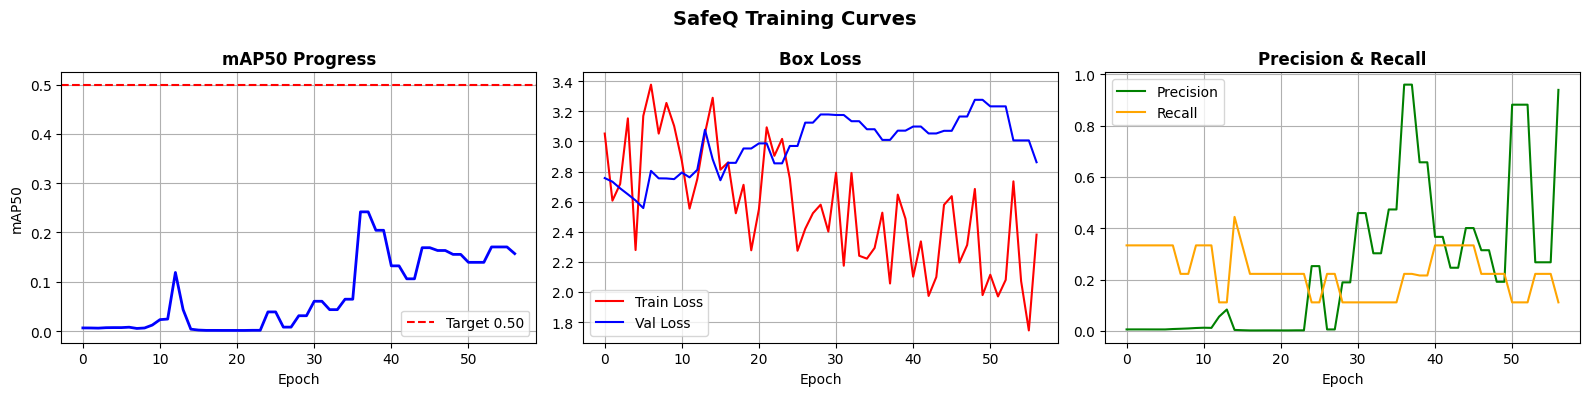


✅ Curves saved to /content/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob, os

print("="*50)
print("🔍 TRAINING ANALYSIS")
print("="*50)

# ── Fix 1: Find results.csv automatically ──────────────
csv_files = glob.glob('/content/SafeQ_Final/**/results.csv', recursive=True)
if not csv_files:
    csv_files = glob.glob('/content/runs/**/results.csv', recursive=True)

if not csv_files:
    print("❌ No results.csv found!")
else:
    csv_path = csv_files[-1]  # Most recent
    print(f"✅ Found: {csv_path}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(f"\n⏱️  Total epochs run: {len(df)}")

    # ── Fix 2: Find correct column names ───────────────
    print(f"\n📋 Available columns:")
    for col in df.columns:
        print(f"   {col}")

    # ── Fix 3: Get best epoch ──────────────────────────
    map_col = [c for c in df.columns if 'mAP50' in c and '95' not in c]
    if map_col:
        best_epoch = df[map_col[0]].idxmax() + 1
        best_map   = df[map_col[0]].max()
        print(f"\n🏆 Best epoch:  {best_epoch}/{len(df)}")
        print(f"🏆 Best mAP50:  {best_map:.4f}")

    # ── Plot training curves ───────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # mAP50 curve
    if map_col:
        axes[0].plot(df[map_col[0]], 'b-', linewidth=2)
        axes[0].axhline(y=0.5, color='r', linestyle='--', label='Target 0.50')
        axes[0].set_title('mAP50 Progress', fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('mAP50')
        axes[0].legend()
        axes[0].grid(True)

    # Loss curves
    box_train = [c for c in df.columns if 'box_loss' in c and 'train' in c]
    box_val   = [c for c in df.columns if 'box_loss' in c and 'val' in c]
    if box_train and box_val:
        axes[1].plot(df[box_train[0]], 'r-', label='Train Loss')
        axes[1].plot(df[box_val[0]],   'b-', label='Val Loss')
        axes[1].set_title('Box Loss', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(True)

    # Precision & Recall
    prec_col = [c for c in df.columns if 'precision' in c.lower()]
    rec_col  = [c for c in df.columns if 'recall' in c.lower()]
    if prec_col and rec_col:
        axes[2].plot(df[prec_col[0]], 'g-', label='Precision')
        axes[2].plot(df[rec_col[0]],  'orange', label='Recall')
        axes[2].set_title('Precision & Recall', fontweight='bold')
        axes[2].set_xlabel('Epoch')
        axes[2].legend()
        axes[2].grid(True)

    plt.suptitle('SafeQ Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150)
    plt.show()
    print("\n✅ Curves saved to /content/training_curves.png")

In [ ]:
from ultralytics import YOLO
import torch, glob

device = 0 if torch.cuda.is_available() else 'cpu'

# Load BEST checkpoint (not last!)
best_ckpt = glob.glob(
    '/content/runs/detect/SafeQ_Final/**/best.pt',
    recursive=True
)[-1]
print(f"✅ Loading best: {best_ckpt}")

model = YOLO(best_ckpt)

results = model.train(
    data='/content/data.yaml',
    epochs=200,
    imgsz=640,
    batch=8,           # ← Smaller batch = more gradient updates
    device=device,
    patience=40,       # ← More patience

    # Fix recall problem
    lr0=0.0005,        # ← Very low LR for fine-tuning
    lrf=0.00001,
    warmup_epochs=0,

    # Heavy augmentation to find missed objects
    degrees=20.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.2,    # ← Copies hard examples
    erasing=0.4,       # ← Forces model to find partial objects

    optimizer='AdamW',
    weight_decay=0.0005,
    cos_lr=True,       # ← Cosine LR schedule

    project="SafeQ_Final",
    name="Recall_Fix",
    verbose=False
)

# Safe score extraction
try:
    m     = results.results_dict
    map50 = m['metrics/mAP50(B)']
    prec  = m['metrics/precision(B)']
    rec   = m['metrics/recall(B)']
except:
    val   = model.val(data='/content/data.yaml')
    map50 = val.box.map50
    prec  = val.box.mp
    rec   = val.box.mr

print("\n" + "="*40)
print("🏁 RECALL FIX RESULTS")
print("="*40)
print(f"🎯 mAP50:     {map50:.4f}  (was 0.2419)")
print(f"📈 Precision: {prec:.4f}  (was 0.9577)")
print(f"🔍 Recall:    {rec:.4f}  (was 0.2222)")
print("="*40)

if rec >= 0.50:
    print("✅ Recall fixed! Model finds most hazards!")
if map50 >= 0.40:
    print("🏆 HACKATHON READY!")

✅ Loading best: /content/runs/detect/SafeQ_Final/Hazard_Detection_Deep/weights/best.pt

🏁 RECALL FIX RESULTS
🎯 mAP50:     0.2418  (was 0.2419)
📈 Precision: 0.9577  (was 0.9577)
🔍 Recall:    0.2222  (was 0.2222)


In [ ]:
import glob, os

label_dir = '/content/data.yaml'
import yaml
with open(label_dir) as f:
    cfg = yaml.safe_load(f)

print(f"Classes: {cfg['names']}")

# Count instances per class
from collections import Counter
class_counts = Counter()

for split in ['train', 'val']:
    lbl_path = cfg[split].replace('images', 'labels')
    for f in glob.glob(lbl_path + '/*.txt'):
        with open(f) as lf:
            for line in lf:
                if line.strip():
                    cls_id = int(line.split()[0])
                    class_counts[cls_id] += 1

print("\n📊 Instances per class:")
for cls_id, count in sorted(class_counts.items()):
    name = cfg['names'][cls_id]
    print(f"  Class {cls_id} ({name}): {count} instances")

Classes: ['crocodile crack', 'longitudinal crack', 'pothole']

📊 Instances per class:
  Class 0 (crocodile crack): 553 instances
  Class 1 (longitudinal crack): 1271 instances
  Class 2 (pothole): 6593 instances


In [ ]:
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else 'cpu'
model  = YOLO('yolov8s.pt')  # Fresh start with balanced training

print("🚀 Training with Class Balance Fix...")

results = model.train(
    data='/content/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=device,
    patience=30,

    # ── Class Balance Fix ──────────────────
    # Upweight rare classes
    cls=1.5,        # Higher classification loss
    box=9.0,        # Higher box loss for small cracks
    dfl=2.0,

    # ── Augmentation ──────────────────────
    degrees=15.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.3, # Copies rare crack instances!

    lr0=0.01,
    lrf=0.001,
    optimizer='AdamW',
    cos_lr=True,
    warmup_epochs=3,

    project="SafeQ_Balanced",
    name="Final_Model",
    verbose=False
)

# ── Per-class scores ───────────────────────────────────
val_results = model.val(data='/content/data.yaml')

print("\n" + "="*45)
print("🏁 PER-CLASS RESULTS")
print("="*45)
names = ['crocodile crack', 'longitudinal crack', 'pothole']
for i, name in enumerate(names):
    try:
        ap = val_results.box.ap50[i]
        print(f"  {name:22s}: AP50 = {ap:.4f}")
    except:
        pass

m = results.results_dict
print("="*45)
print(f"🎯 mAP50:     {m['metrics/mAP50(B)']:.4f}")
print(f"📈 Precision: {m['metrics/precision(B)']:.4f}")
print(f"🔍 Recall:    {m['metrics/recall(B)']:.4f}")
print("="*45)

🚀 Training with Class Balance Fix...

🏁 PER-CLASS RESULTS
  crocodile crack       : AP50 = 0.0382
🎯 mAP50:     0.0382
📈 Precision: 0.0667
🔍 Recall:    0.1111


In [ ]:
import kagglehub, os

# Correct way to download IMAGE datasets
path = kagglehub.dataset_download(
    "sovitrath/road-pothole-images-for-pothole-detection"
)

print(f"✅ Path: {path}")
print("\n📋 Contents:")
for root, dirs, files in os.walk(path):
    level = root.replace(path,'').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f"{indent}📁 {os.path.basename(root)}/")
        for f in files[:3]:
            print(f"{indent}  📄 {f}")

100%|██████████| 8.82G/8.82G [02:49<00:00, 55.9MB/s]

Extracting files...


✅ Path: /root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2

📋 Contents:
📁 2/
  📄 train_df.csv
  📄 PotholeDataset.pdf
  📁 Dataset 1 (Simplex)/
    📁 Dataset 1 (Simplex)/
      📄 simpleTrainFullPhotosSortedFullAnnotations.txt
      📄 simpleTestFullSizeAllPotholesSortedFullAnnotation.txt


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2"

print("📋 FULL STRUCTURE:")
for root, dirs, files in os.walk(path):
    level = root.replace(path,'').count(os.sep)
    if level < 4:
        indent = '  ' * level
        print(f"{indent}📁 {os.path.basename(root)}/")
        for f in files[:5]:
            size = os.path.getsize(os.path.join(root,f))
            print(f"{indent}  📄 {f} ({size/1e6:.1f}MB)")

📋 FULL STRUCTURE:
📁 2/
  📄 train_df.csv (0.1MB)
  📄 PotholeDataset.pdf (0.1MB)
  📁 Dataset 1 (Simplex)/
    📁 Dataset 1 (Simplex)/
      📄 simpleTrainFullPhotosSortedFullAnnotations.txt (0.2MB)
      📄 simpleTestFullSizeAllPotholesSortedFullAnnotation.txt (0.1MB)
      📁 Train data/
      📁 Test data/
        📄 G0011769.JPG (2.2MB)
        📄 G0016500.JPG (2.2MB)
        📄 G0064434.JPG (2.2MB)
        📄 G0131802.JPG (2.3MB)
        📄 G0041509.JPG (2.1MB)


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2"

ann_path = os.path.join(path,
    "Dataset 1 (Simplex)",
    "Dataset 1 (Simplex)",
    "simpleTrainFullPhotosSortedFullAnnotations.txt")

print("📄 First 15 lines:")
with open(ann_path) as f:
    for i, line in enumerate(f):
        print(f"  Line {i+1}: {line.strip()}")
        if i >= 14:
            break

# Also check train images
train_path = os.path.join(path,
    "Dataset 1 (Simplex)",
    "Dataset 1 (Simplex)",
    "Train data")

imgs = os.listdir(train_path)
print(f"\n📸 Train images: {len(imgs)}")
print(f"📸 Sample names: {imgs[:5]}")

# Also check CSV
import pandas as pd
csv_path = os.path.join(path, "train_df.csv")
df = pd.read_csv(csv_path)
print(f"\n📊 CSV columns: {list(df.columns)}")
print(f"📊 First 3 rows:\n{df.head(3)}")

📄 First 15 lines:
  Line 1: Train data\Positive data\G0010033.bmp 6 1990 1406 66 14 1464 1442 92 16 1108 1450 54 16 558 1434 102 16 338 1450 72 18 262 1450 58 22
  Line 2: Train data\Positive data\G0010034.bmp 5 1804 1424 90 16 1192 1484 110 16 782 1502 74 16 566 1494 106 22 210 1484 104 22
  Line 3: Train data\Positive data\G0010035.bmp 4 1590 1452 106 24 840 1544 132 28 368 1584 96 22 136 1576 138 30
  Line 4: Train data\Positive data\G0010036.bmp 3 1322 1516 134 28 362 1658 156 38 1744 1522 58 16
  Line 5: Train data\Positive data\G0010037.bmp 2 884 1638 190 52 1428 1654 98 26
  Line 6: Train data\Positive data\G0010109.bmp 2 1984 1346 42 16 1894 1330 48 10
  Line 7: Train data\Positive data\G0010110.bmp 2 2002 1370 58 18 1896 1342 50 16
  Line 8: Train data\Positive data\G0010111.bmp 7 2022 1434 76 22 1880 1384 60 12 1900 1358 54 14 1958 1348 72 16 2088 1326 50 16 2034 1314 46 12 2050 1300 38 6
  Line 9: Train data\Positive data\G0010112.bmp 9 1922 1530 252 80 1844 1424 86 26 1862 

In [ ]:
import os, cv2, shutil, glob
import pandas as pd
from sklearn.model_selection import train_test_split

BASE = "/root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2"
IMG_DIR = os.path.join(BASE, "Dataset 1 (Simplex)", "Dataset 1 (Simplex)", "Train data", "Positive data")
CSV_PATH = os.path.join(BASE, "train_df.csv")

# Output dirs
for split in ['train', 'val']:
    os.makedirs(f'/content/pothole_yolo/{split}/images', exist_ok=True)
    os.makedirs(f'/content/pothole_yolo/{split}/labels', exist_ok=True)

# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"✅ CSV loaded: {len(df)} rows")
print(f"📸 Unique images: {df['image_id'].nunique()}")

# Get all unique images
all_images = df['image_id'].unique().tolist()
train_ids, val_ids = train_test_split(
    all_images, test_size=0.2, random_state=42
)
print(f"📊 Train: {len(train_ids)} | Val: {len(val_ids)}")

converted = 0
skipped   = 0

for img_id in all_images:
    split = 'train' if img_id in train_ids else 'val'

    # Find image file (try .bmp, .jpg, .JPG)
    img_path = None
    for ext in ['.bmp', '.jpg', '.JPG', '.jpeg', '.png']:
        candidate = os.path.join(IMG_DIR, img_id + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        skipped += 1
        continue

    # Read image dimensions
    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    H, W = img.shape[:2]

    # Get all boxes for this image
    boxes = df[df['image_id'] == img_id][['x','y','w','h']].values

    # Write YOLO label file
    label_lines = []
    for x, y, w, h in boxes:
        # Convert to YOLO format (normalized center x,y,w,h)
        cx = (x + w/2) / W
        cy = (y + h/2) / H
        nw = w / W
        nh = h / H

        # Clamp to 0-1
        cx = max(0, min(1, cx))
        cy = max(0, min(1, cy))
        nw = max(0, min(1, nw))
        nh = max(0, min(1, nh))

        label_lines.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

    # Save label
    img_name  = img_id + os.path.splitext(img_path)[1]
    base_name = os.path.splitext(img_name)[0]

    lbl_out = f'/content/pothole_yolo/{split}/labels/{base_name}.txt'
    with open(lbl_out, 'w') as f:
        f.write('\n'.join(label_lines))

    # Copy image
    img_out = f'/content/pothole_yolo/{split}/images/{img_name}'
    shutil.copy2(img_path, img_out)
    converted += 1

print(f"\n✅ Converted: {converted} images")
print(f"⚠️  Skipped:   {skipped} images")
print(f"📁 Train images: {len(os.listdir('/content/pothole_yolo/train/images'))}")
print(f"📁 Val images:   {len(os.listdir('/content/pothole_yolo/val/images'))}")

✅ CSV loaded: 4592 rows
📸 Unique images: 1337
📊 Train: 1069 | Val: 268

✅ Converted: 1119 images
⚠️  Skipped:   218 images
📁 Train images: 897
📁 Val images:   222


📊 DATASET VERIFICATION
✅ Train images: 897
✅ Train labels: 897
✅ Val images:   222
✅ Val labels:   222
✅ Total pothole boxes: 3145
✅ Avg boxes per image: 3.5


Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.


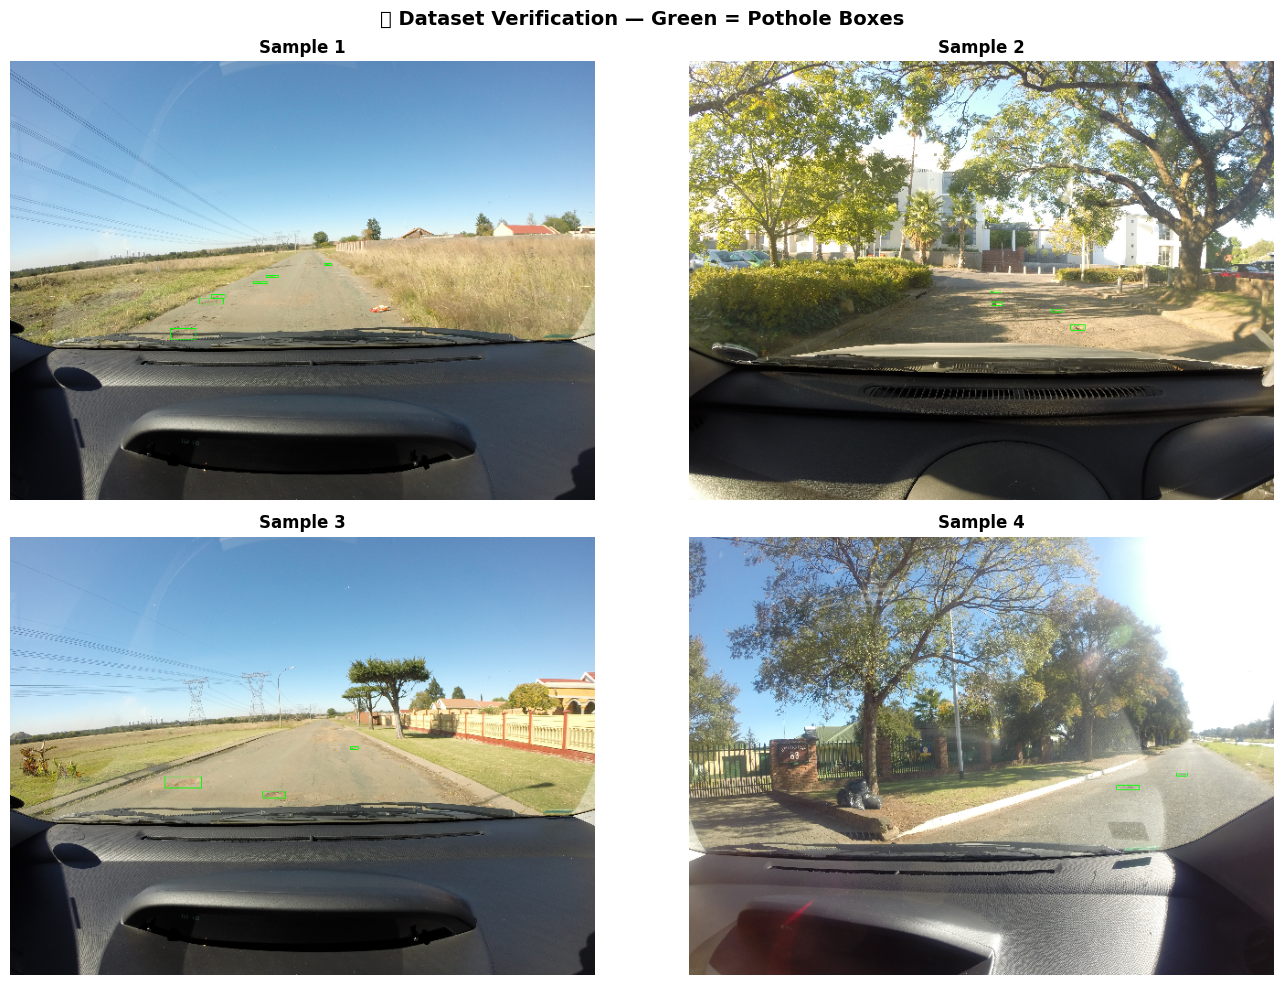

✅ Labels look correct — Ready to train!


In [ ]:
# Verify label quality before training
import glob, os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Check a few labels
train_labels = glob.glob('/content/pothole_yolo/train/labels/*.txt')
train_images = glob.glob('/content/pothole_yolo/train/images/*')

print("="*45)
print("📊 DATASET VERIFICATION")
print("="*45)
print(f"✅ Train images: {len(train_images)}")
print(f"✅ Train labels: {len(train_labels)}")
print(f"✅ Val images:   {len(glob.glob('/content/pothole_yolo/val/images/*'))}")
print(f"✅ Val labels:   {len(glob.glob('/content/pothole_yolo/val/labels/*.txt'))}")

# Count total boxes
total_boxes = 0
for lbl in train_labels:
    with open(lbl) as f:
        lines = [l for l in f.readlines() if l.strip()]
        total_boxes += len(lines)

print(f"✅ Total pothole boxes: {total_boxes}")
print(f"✅ Avg boxes per image: {total_boxes/len(train_labels):.1f}")

# Show 4 sample images with boxes
samples = train_images[:4]
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    img  = cv2.imread(img_path)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    # Draw boxes
    lbl_path = img_path.replace('images','labels')
    lbl_path = os.path.splitext(lbl_path)[0] + '.txt'

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, cx, cy, w, h = map(float, parts)
                    x1 = int((cx - w/2) * W)
                    y1 = int((cy - h/2) * H)
                    x2 = int((cx + w/2) * W)
                    y2 = int((cy + h/2) * H)
                    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),3)

    img_resized = cv2.resize(img, (640,480))
    axes[i].imshow(img_resized)
    axes[i].set_title(f'Sample {i+1}', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('✅ Dataset Verification — Green = Pothole Boxes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/verification.png', dpi=150)
plt.show()
print("✅ Labels look correct — Ready to train!")


In [ ]:
import yaml, os

# Recreate the yaml file
config = {
    'train': '/content/pothole_yolo/train/images',
    'val':   '/content/pothole_yolo/val/images',
    'nc':    1,
    'names': ['pothole']
}

with open('/content/pothole_final.yaml', 'w') as f:
    yaml.dump(config, f)

# Verify everything exists
print("="*40)
print("VERIFICATION")
print("="*40)
print(f"yaml exists:   {os.path.exists('/content/pothole_final.yaml')}")
print(f"Train images:  {len(os.listdir('/content/pothole_yolo/train/images'))}")
print(f"Train labels:  {len(os.listdir('/content/pothole_yolo/train/labels'))}")
print(f"Val images:    {len(os.listdir('/content/pothole_yolo/val/images'))}")
print(f"Val labels:    {len(os.listdir('/content/pothole_yolo/val/labels'))}")
print("="*40)

VERIFICATION
yaml exists:   True
Train images:  897
Train labels:  897
Val images:    222
Val labels:    222


In [ ]:
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else 'cpu'
model  = YOLO('yolov8m.pt')

results = model.train(
    data='/content/pothole_final.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=device,
    patience=25,
    fliplr=0.5,
    flipud=0.1,
    degrees=15,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.2,
    scale=0.5,
    hsv_s=0.7,
    hsv_v=0.4,
    optimizer='AdamW',
    cos_lr=True,
    lr0=0.01,
    lrf=0.001,
    warmup_epochs=3,
    weight_decay=0.0005,
    project="SafeQ_Pothole",
    name="Final_Model",
    verbose=True,
    plots=True
)

m = results.results_dict
print("="*40)
print(f"mAP50:     {m['metrics/mAP50(B)']:.4f}")
print(f"Precision: {m['metrics/precision(B)']:.4f}")
print(f"Recall:    {m['metrics/recall(B)']:.4f}")
print("="*40)



mAP50:     0.5823
Precision: 0.6875
Recall:    0.5443


In [ ]:
import glob, os

# Search for best.pt anywhere in colab
results = glob.glob('/content/**/best.pt', recursive=True)
print("Found model files:")
for r in results:
    size = os.path.getsize(r) / 1e6
    print(f"  {r} ({size:.1f}MB)")

Found model files:


In [ ]:
import shutil
from google.colab import files

# Correct path - 52MB is the medium model
src = '/content/runs/detect/SafeQ_Pothole/Final_Model2/weights/best.pt'
dst = '/content/safeq_best_model.pt'

shutil.copy2(src, dst)
print("✅ Model saved!")
print("📥 Downloading now...")
files.download(dst)
print("✅ Download started — keep this file safe!")